# HW 2

**Sepehr Ilami**

**Otober 2025**

**Github Link**:
**https://github.com/sepehrilami/phys7332_fa25/blob/main/assignments/assignment02.ipynb**

## Question 1

### a) Redis

**Data Structure:**  
Redis is an **in-memory key-value store**. Data is stored as pairs of keys and values, where values can be various data types such as strings, lists, sets, sorted sets, and hashes.

**Best For:**  
Redis excels in **high-speed, real-time applications** requiring rapid read/write operations and low latency. Common use cases include:
- Caching frequently accessed data
- Session management
- Leaderboards and counters
- Real-time analytics

**Bad Use Case:**  
Redis is **poorly suited for long-term data storage** or **complex querying** (e.g., relational joins or aggregations). Because it stores data in memory, large datasets can be expensive to maintain and are not persistent by default.


### b) MongoDB

**Data Structure:**  
MongoDB is a **document-oriented database** that stores data in **BSON (binary JSON)** format. Documents are grouped into collections, allowing for flexible, schema-less data storage.

**Best For:**  
MongoDB is ideal for **semi-structured or evolving datasets**, where flexibility and scalability are important. Typical applications include:
- Content management systems (CMS)
- E-commerce product catalogs
- Mobile or web app backends
- Real-time analytics dashboards

**Bad Use Case:**  
MongoDB is **not well-suited for complex transactions or strong consistency requirements** across multiple documents. Financial applications requiring atomic multi-table operations (like bank transfers) perform better in relational databases.


### c) Cassandra

**Data Structure:**  
Cassandra is a **wide-column store**, inspired by Google’s Bigtable. Data is stored in rows and columns but grouped into **column families** instead of traditional tables. It is designed for distributed, horizontally scalable systems.

**Best For:**  
Cassandra shines in **highly available, write-heavy environments** with massive, distributed datasets. Common use cases include:
- Time-series data (e.g., IoT sensors, logs)
- Messaging platforms
- Recommendation systems
- Global-scale applications requiring fault tolerance

**Bad Use Case:**  
Cassandra is **not ideal for ad-hoc queries or applications needing complex joins or aggregations**. Its query language (CQL) is limited in analytical functionality, making it unsuitable for business intelligence systems or highly relational data.


### d) Neo4j

**Data Structure:**  
Neo4j is a **graph database** that stores data as **nodes, relationships, and properties**. It uses the Cypher query language to express graph patterns efficiently.

**Best For:**  
Neo4j is built for **data that is highly interconnected**, where relationships are very important. It's actually ideal for network science and this course. Use cases include:
- Social networks
- Fraud detection
- Knowledge graphs
- Recommendation engines

**Bad Use Case:**  
Neo4j is **poorly suited for applications centered on flat, tabular data** or those requiring complex aggregations across unrelated entities. For example, large-scale financial reporting or bulk numerical computations would perform better in a relational or analytical (OLAP) database.


| Database | Data Model | Best For | Poor Fit |
|-----------|-------------|----------|-----------|
| **Redis** | Key-value (in-memory) | Caching, real-time analytics | Long-term storage, complex queries |
| **MongoDB** | Document (BSON/JSON) | Flexible schemas, web apps | Multi-document transactions |
| **Cassandra** | Wide-column | Distributed, high-write workloads | Complex queries, BI analytics |
| **Neo4j** | Graph (nodes + edges) | Relationship-heavy data | Flat or numerical datasets |


## Question 2

In [50]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import scipy.sparse as sp
import time
import seaborn as sns
import pandas as pd
import os
import community as community_louvain
import warnings
warnings.filterwarnings("ignore")
import random
import scipy.io
from graph_tool.all import *
from sklearn.metrics import normalized_mutual_info_score


### a)

We will use an interaction network. It's the email communication network at the University Rovira i Virgili in Tarragona in the south of Catalonia in Spain. Nodes are users and edges indicate that at least one email was sent.

citation:

Rossi, R. A., & Ahmed, N. K. (2015). The Network Data Repository with Interactive Graph Analytics and Visualization. In Proceedings of the AAAI Conference on Artificial Intelligence (Vol. 29, No. 1). https://networkrepository.com

Roger Guimera, Leon Danon, Albert Diaz-Guilera, Francesc Giralt, and Alex Arenas. 2003. Self-similar community structure in a network of human interactions. Physical review E 68, 6 (2003), 065103.

In [23]:
# load the data from data/ia-email-univ/ia-email-univ.mtx using networkx
data = scipy.io.mmread('../data/ia-email-univ/ia-email-univ.mtx')

# Select a modularity maximization algorithm to detect communities in this graph: Louvain
# Convert the sparse matrix to a NetworkX graph
G = nx.from_scipy_sparse_array(data)
G = G.to_undirected()
G.remove_edges_from(nx.selfloop_edges(G))
# if the graph is not connected, take the largest connected component
if not nx.is_connected(G):
    print("Graph is not connected. Taking the largest connected component.")
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")
# Ensure the graph is connected
if not nx.is_connected(G):
    raise ValueError("The graph is not connected.")

# Do community detection using Louvain method
start_time = time.time()
partition = community_louvain.best_partition(G, random_state=42)
end_time = time.time()
louvain_time = end_time - start_time
print(f"Louvain method took {louvain_time:.4f} seconds.")

Graph has 1133 nodes and 5451 edges.
Louvain method took 0.1153 seconds.


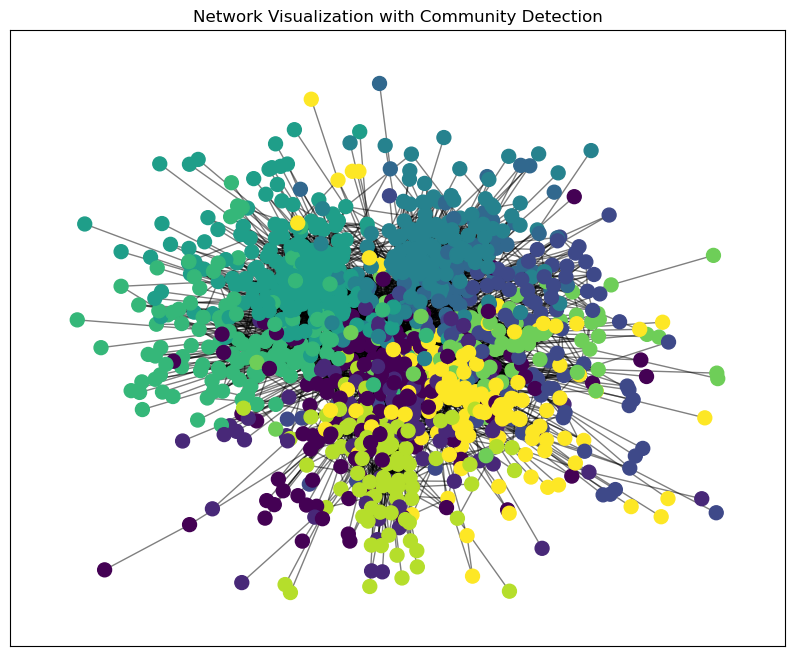

In [24]:
# Simple Visualization
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
num_communities = len(set(partition.values()))
cmap = plt.get_cmap("viridis", num_communities)
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=100, cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.title("Network Visualization with Community Detection")
plt.show()

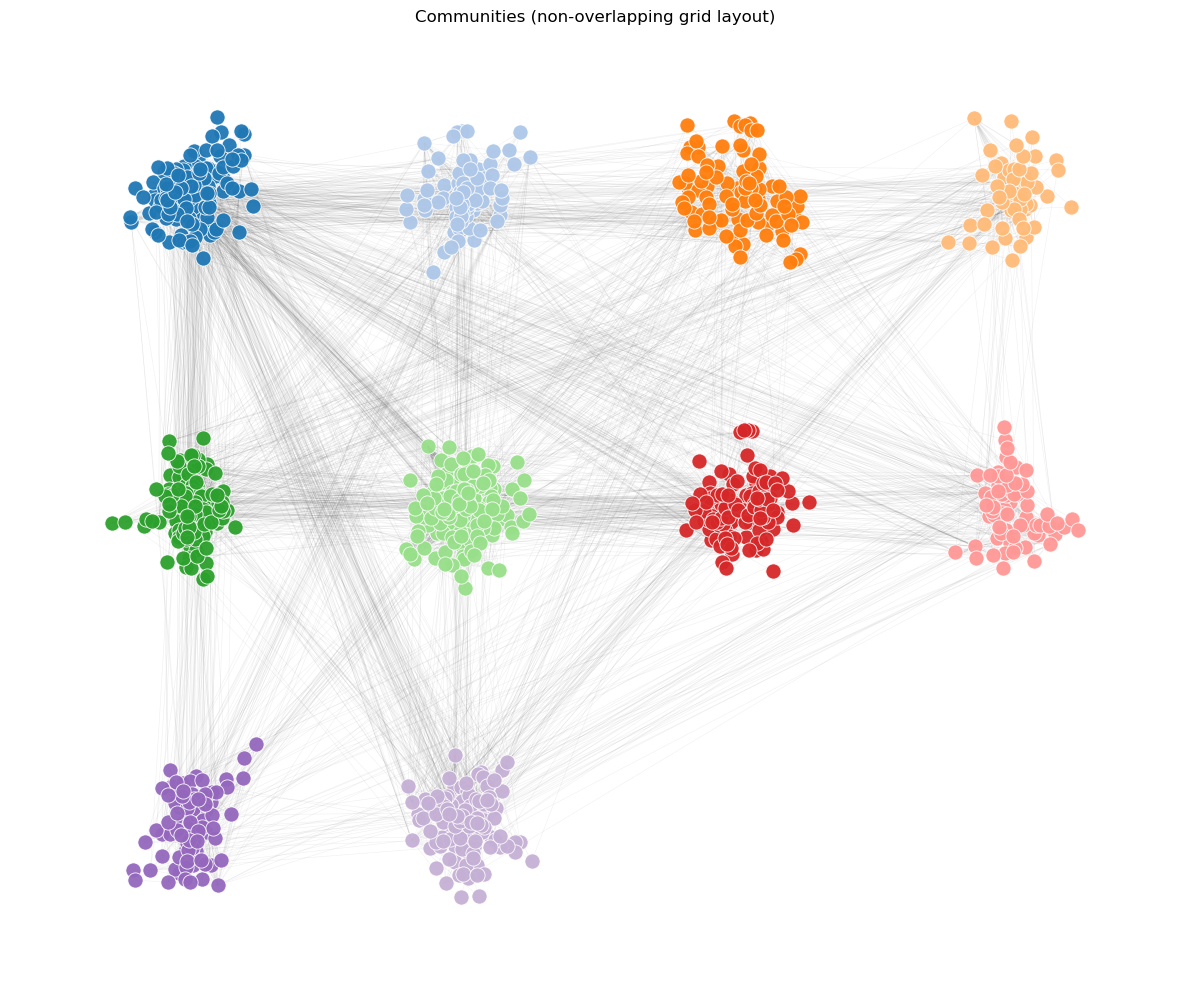

In [25]:
# Complicated visualization: Non-overlapping community layout
def plot_communities_separated(G, partition, seed=42,
                               cell_size=4.0,   # spacing between community centers
                               cluster_scale=0.9 # how much of the cell to fill (0-1)
                              ):
    """
    Draw communities in a non-overlapping grid.
    Each community gets a cell; nodes are spring-laid inside that cell and then shifted.
    """
    # --- group nodes by community
    comm2nodes = defaultdict(list)
    for n, c in partition.items():
        comm2nodes[c].append(n)
    communities = sorted(comm2nodes.keys())
    C = len(communities)

    # --- choose grid size (rows x cols)
    cols = int(np.ceil(np.sqrt(C)))
    rows = int(np.ceil(C / cols))

    # --- community centers on a grid
    centers = {}
    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx >= C: break
            cx = c * cell_size
            cy = -r * cell_size
            centers[communities[idx]] = (cx, cy)
            idx += 1

    # --- colors (categorical)
    base = plt.get_cmap("tab20").colors
    palette = (list(base) * ((C // len(base)) + 1))[:C]
    color_for = {comm: palette[i] for i, comm in enumerate(communities)}

    # --- compute inner layouts and compose global positions
    rng = np.random.default_rng(seed)
    pos = {}
    for comm in communities:
        nodes = comm2nodes[comm]
        sub = G.subgraph(nodes)
        inner = nx.spring_layout(sub, seed=int(rng.integers(0, 1_000_000)))
        # normalize to a unit box so all communities fit similarly in their cells
        arr = np.array(list(inner.values()))
        if len(arr) > 1:
            arr = (arr - arr.mean(0))
            denom = np.ptp(arr, axis=0)  # NumPy 2.0 safe
            denom[denom == 0] = 1.0
            arr = arr / denom
        scale = (cell_size * 0.5) * cluster_scale
        cx, cy = centers[comm]
        for node, (x, y) in zip(nodes, arr):
            pos[node] = (cx + scale * x, cy + scale * y)

    # --- edge and node drawing
    plt.figure(figsize=(12, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.4, edge_color="#444444")

    for comm in communities:
        nodelist = comm2nodes[comm]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodelist,
            node_color=[color_for[comm]],
            node_size=120,
            edgecolors="white", linewidths=0.6, alpha=0.95
        )

    plt.axis("off")
    plt.title("Communities (non-overlapping grid layout)", pad=10)
    plt.tight_layout()
    plt.show()

plot_communities_separated(G, partition, seed=42, cell_size=4.0, cluster_scale=0.9)

In [26]:
# Report the modularity of the partition your algorithm found
modularity = community_louvain.modularity(partition, G)
print(f"Modularity of the partition: {modularity:.4f}")
# Number of communities
num_communities = len(set(partition.values()))
print(f"Number of communities detected: {num_communities}")

Modularity of the partition: 0.5702
Number of communities detected: 10


In [27]:
# Store your partition as a dictionary, in the form of {node id: community id}
partition_dict = partition
# Save the partition to a text file, inside the other_stuff folder
if not os.path.exists('other_stuff'):
    os.makedirs('other_stuff')
with open('other_stuff/louvain_partition.txt', 'w') as f:
    for node, comm in partition_dict.items():
        f.write(f"{node}\t{comm}\n")


### b)

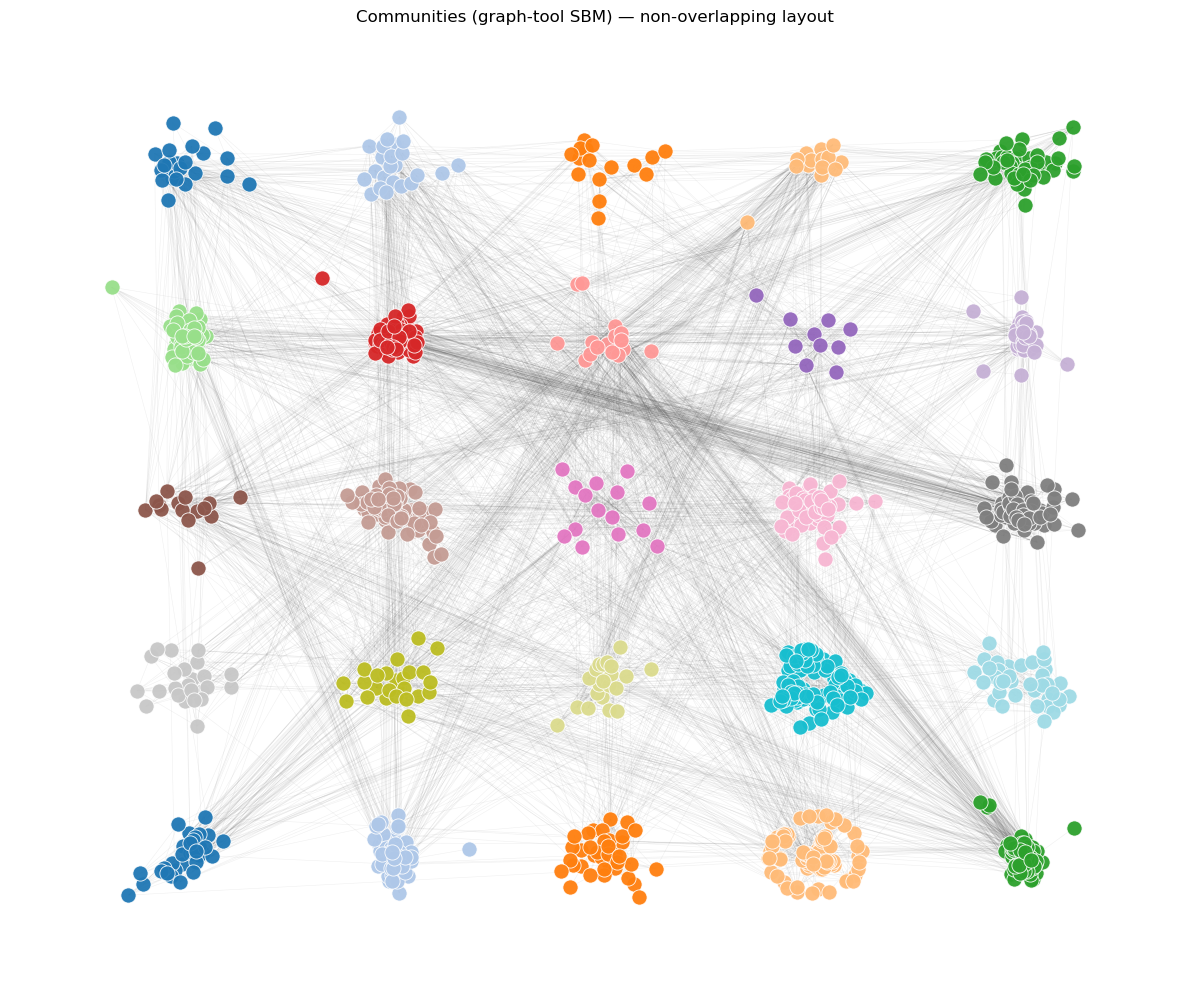

In [39]:
# --- COMMUNITY DETECTION WITH GRAPH-TOOL, THEN REUSE YOUR PLOTTER ---

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import graph_tool.all as gt   # <-- make sure graph-tool is installed

# 1) Helper: convert NetworkX -> graph-tool (keeps a name property for mapping back)
def nx_to_gt(G):
    g = gt.Graph(directed=G.is_directed())
    v_name = g.new_vertex_property("object")
    g.vp["name"] = v_name

    nx2gt = {}
    for n in G.nodes():
        v = g.add_vertex()
        nx2gt[n] = v
        v_name[v] = n

    # (optional) pass weights if present
    has_w = any(("weight" in d) for _, _, d in G.edges(data=True))
    if has_w:
        e_w = g.new_edge_property("double")
        g.ep["weight"] = e_w

    for u, v, d in G.edges(data=True):
        e = g.add_edge(nx2gt[u], nx2gt[v])
        if has_w:
            g.ep["weight"][e] = float(d.get("weight", 1.0))

    return g, nx2gt

# 2) Community detection via SBM minimum description length
def gt_sbm_partition(G, seed=42, use_edge_weights=True):
    g, nx2gt = nx_to_gt(G)
    # If you want to consider weights, graph-tool handles them via "recs"/"rec_types"
    # but a simple, robust starting point is to ignore weights:
    state = gt.minimize_blockmodel_dl(g)
    blocks = state.get_blocks()
    partition = {n: int(blocks[nx2gt[n]]) for n in G.nodes()}
    return partition, state, blocks

# 3) Your existing non-overlapping plotter (unchanged)
def plot_communities_separated(G, partition, seed=42,
                               cell_size=4.0,
                               cluster_scale=0.9):
    from collections import defaultdict
    comm2nodes = defaultdict(list)
    for n, c in partition.items():
        comm2nodes[c].append(n)
    communities = sorted(comm2nodes.keys())
    C = len(communities)

    cols = int(np.ceil(np.sqrt(C)))
    rows = int(np.ceil(C / cols))

    centers, idx = {}, 0
    for r in range(rows):
        for c in range(cols):
            if idx >= C: break
            centers[communities[idx]] = (c * cell_size, -r * cell_size)
            idx += 1

    base = plt.get_cmap("tab20").colors
    palette = (list(base) * ((C // len(base)) + 1))[:C]
    color_for = {comm: palette[i] for i, comm in enumerate(communities)}

    rng = np.random.default_rng(seed)
    pos = {}
    for comm in communities:
        nodes = comm2nodes[comm]
        sub = G.subgraph(nodes)
        inner = nx.spring_layout(sub, seed=int(rng.integers(0, 1_000_000)))
        arr = np.array(list(inner.values()))
        if len(arr) > 1:
            arr = (arr - arr.mean(0))
            denom = np.ptp(arr, axis=0)
            denom[denom == 0] = 1.0
            arr = arr / denom
        scale = (cell_size * 0.5) * cluster_scale
        cx, cy = centers[comm]
        for node, (x, y) in zip(nodes, arr):
            pos[node] = (cx + scale * x, cy + scale * y)

    plt.figure(figsize=(12, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.08, width=0.4, edge_color="#444444")
    for comm in communities:
        nodelist = comm2nodes[comm]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=nodelist,
            node_color=[color_for[comm]],
            node_size=120,
            edgecolors="white", linewidths=0.6, alpha=0.95
        )
    plt.axis("off")
    plt.title("Communities (graph-tool SBM) — non-overlapping layout", pad=10)
    plt.tight_layout()
    plt.show()

# ---- Run it ----
partition_gt, state, blocks = gt_sbm_partition(G)      # 1) detect with graph-tool
plot_communities_separated(G, partition_gt, seed=42,  # 2) same layout function as before
                           cell_size=4.0, cluster_scale=0.9)


In [43]:
# Save the partition to a text file, inside the other_stuff folder
with open('other_stuff/graph_tool_partition.txt', 'w') as f:
    for node, comm in partition_gt.items():
        f.write(f"{node}\t{comm}\n")

# number of communities
num_communities_gt = len(set(partition_gt.values()))
print(f"Number of communities detected by graph-tool SBM: {num_communities_gt}")

Number of communities detected by graph-tool SBM: 25


### c)

In [ ]:
G_random = nx.double_edge_swap(G.copy(), nswap=5*G.number_of_edges(), max_tries=100*G.number_of_edges(), seed=42)
# Louvain on randomized graph
partition_louvain_random = community_louvain.best_partition(G_random, random_state=42)
# Graph-tool SBM on randomized graph
partition_gt_random, state_random, blocks_random = gt_sbm_partition(G_random)
# Save the partitions to text files
with open('other_stuff/louvain_partition_random.txt', 'w') as f:
    for node, comm in partition_louvain_random.items():
        f.write(f"{node}\t{comm}\n")
with open('other_stuff/graph_tool_partition_random.txt', 'w') as f:
    for node, comm in partition_gt_random.items():
        f.write(f"{node}\t{comm}\n")
# number of communities in randomized graph
num_communities_louvain_random = len(set(partition_louvain_random.values()))
num_communities_gt_random = len(set(partition_gt_random.values()))
print(f"Number of communities detected by Louvain on randomized graph: {num_communities_louvain_random}")
print(f"Number of communities detected by graph-tool SBM on randomized graph: {num_communities_gt_random}")

Number of communities detected by Louvain on randomized graph: 12
Number of communities detected by graph-tool SBM on randomized graph: 1


### d)

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# partitions: list of dicts {node_id: community_id}
# titles: list of subplot titles (same length as partitions)

def _community_sizes(partition):
    # counts of nodes per community
    _, counts = np.unique(list(partition.values()), return_counts=True)
    return counts.astype(int)

def _ccdf_from_sizes(sizes):
    # CCDF P(S >= s) at unique size values
    uniq, counts = np.unique(sizes, return_counts=True)
    tail_counts = np.cumsum(counts[::-1])[::-1]   # >= s counts
    ccdf = tail_counts / tail_counts[0]
    return uniq, ccdf

def plot_community_size_distributions(partitions, titles):
    assert len(partitions) == 4 and len(titles) == 4, "Need exactly four partitions and titles"

    # Precompute for consistent axes across subplots
    all_sizes = [ _community_sizes(p) for p in partitions ]
    max_size = max(int(s.max()) for s in all_sizes)
    max_comms = max(len(s) for s in all_sizes)
    ymin = 1 / max_comms
    xmin, xmax = 1, max(2, max_size)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, sizes, title in zip(axes, all_sizes, titles):
        x, y = _ccdf_from_sizes(sizes)

        # Step plot on log–log axes (discrete sizes)
        ax.step(x, y, where="post", linewidth=2)

        # Styling and labels
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, 1.0)

        ax.set_title(title, pad=8)
        ax.set_xlabel("Community size (nodes)")
        ax.set_ylabel("P(S ≥ s)")

        # Nice tick formatting
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.tick_params(axis='both', which='both', labelsize=9)

        # Small annotation box with summary stats
        n_comms = len(sizes)
        s_med = int(np.median(sizes))
        s_max = int(np.max(sizes))
        ax.text(0.03, 0.04, f"# communities: {n_comms}\nmedian size: {s_med}\nmax size: {s_max}",
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9))

    fig.suptitle("Community Size Distributions (CCDF, log–log)", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

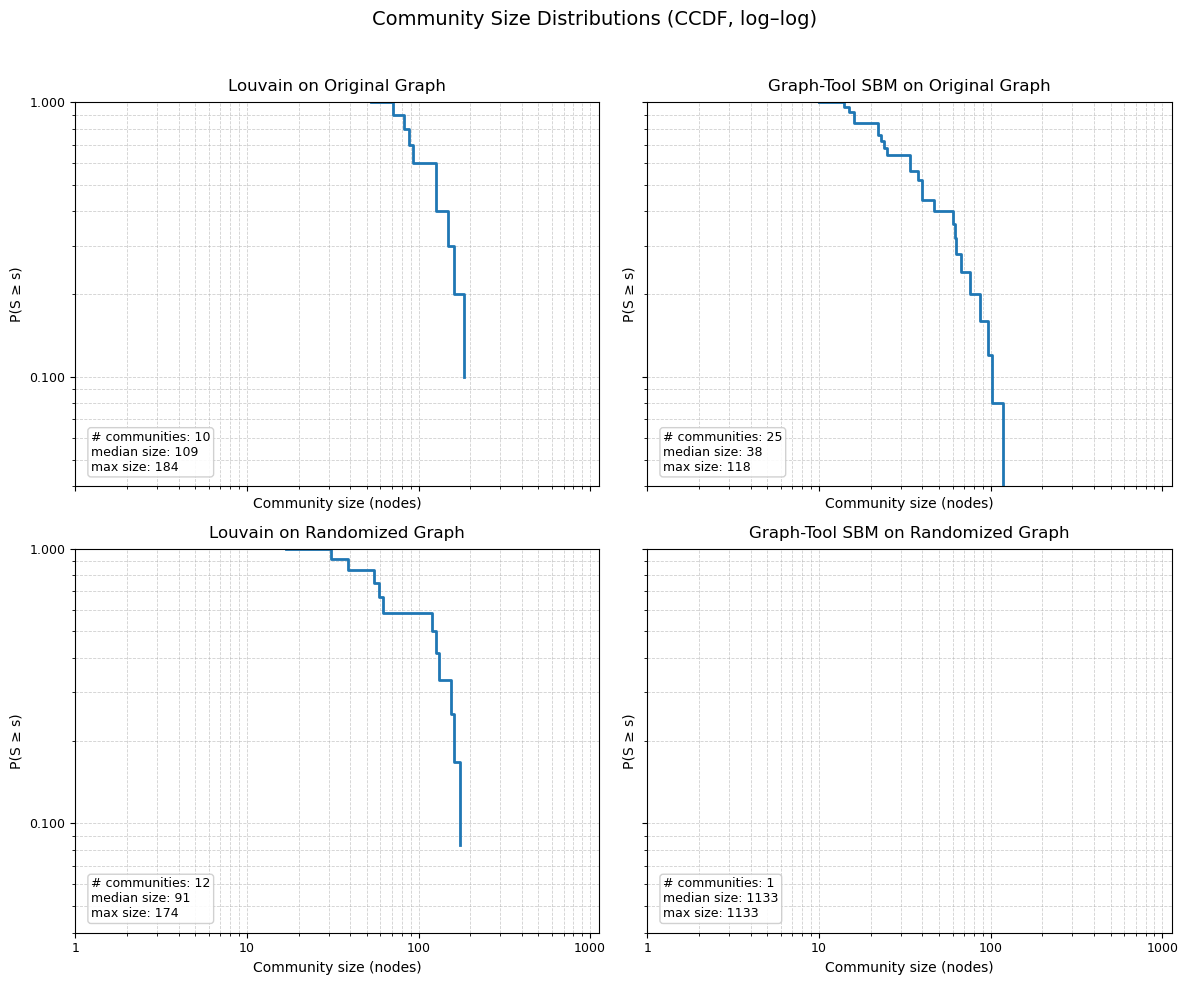

In [47]:
# read the four partitions
with open('other_stuff/louvain_partition.txt', 'r') as f:
    partition = {int(line.split()[0]): int(line.split()[1]) for line in f}
with open('other_stuff/graph_tool_partition.txt', 'r') as f:
    partition_gt = {int(line.split()[0]): int(line.split()[1]) for line in f}
with open('other_stuff/louvain_partition_random.txt', 'r') as f:
    partition_louvain_random = {int(line.split()[0]): int(line.split()[1]) for line in f}
with open('other_stuff/graph_tool_partition_random.txt', 'r') as f:
    partition_gt_random = {int(line.split()[0]): int(line.split()[1]) for line in f}

partitions = [partition, partition_gt, partition_louvain_random, partition_gt_random]
titles = [
    "Louvain on Original Graph",
    "Graph-Tool SBM on Original Graph",
    "Louvain on Randomized Graph",
    "Graph-Tool SBM on Randomized Graph"
]

plot_community_size_distributions(partitions, titles)

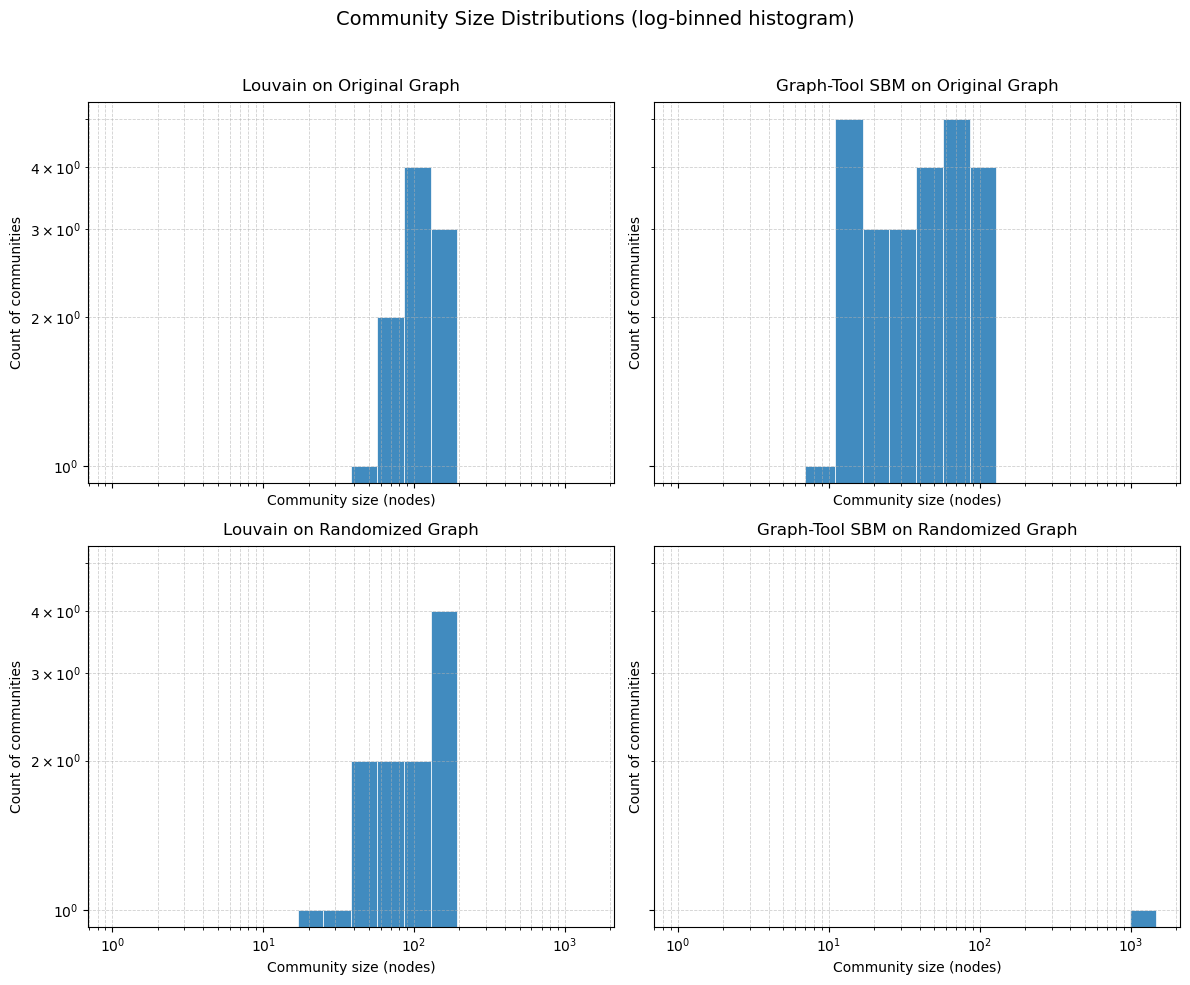

In [55]:
def _log_bins(max_size, base=1.5):
    # geometric progression of bin edges
    edges = [1]
    while edges[-1] < max_size:
        edges.append(edges[-1] * base)
    edges[-1] = max(edges[-1], max_size)
    return np.unique(np.floor(edges)).astype(int)

def plot_histograms(partitions, titles, base=1.5):
    all_sizes = [ _community_sizes(p) for p in partitions ]
    max_size = max(int(s.max()) for s in all_sizes)
    bins = _log_bins(max_size, base=base)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, sizes, title in zip(axes, all_sizes, titles):
        ax.hist(sizes, bins=bins, alpha=0.85, edgecolor="white", linewidth=0.6)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", linewidth=0.6, alpha=0.6)
        ax.set_xlabel("Community size (nodes)")
        ax.set_ylabel("Count of communities")
        ax.set_title(title, pad=8)
    fig.suptitle("Community Size Distributions (log-binned histogram)", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_histograms(partitions, titles, base=1.5)

### e)

There is a well-known algorithm for comparing partitions called Normalized Mutual Information (NMI). It is based on the concept of mutual information from information theory, which measures the amount of information obtained about one random variable through another random variable. In the context of clustering, NMI quantifies the similarity between two different partitions of a dataset.
The formula for NMI is as follows:
NMI(U, V) = 2 * I(U; V) / (H(U) + H(V))
Where:
- I(U; V) is the mutual information between partitions U and V. Calculated as:
I(U; V) = Σ (|Ui ∩ Vj| / N) * log((N * |Ui ∩ Vj|) / (|Ui| * |Vj|))
- H(U) and H(V) are the entropies of partitions U and V, respectively. Calculated as:
H(U) = - Σ (|Ui| / N) * log(|Ui| / N)
H(V) = - Σ (|Vj| / N) * log(|Vj| / N)
- |Ui| is the number of elements in cluster Ui of partition U.
- |Vj| is the number of elements in cluster Vj of partition V.
- |Ui ∩ Vj| is the number of elements that are in both cluster Ui and cluster Vj.
- N is the total number of elements in the dataset.
The NMI value ranges from 0 to 1, where:
- NMI = 1 indicates perfect agreement between the two partitions (i.e., they are identical).
- NMI = 0 indicates no mutual information between the partitions (i.e., they are completely independent).
NMI is particularly useful for evaluating clustering algorithms because it accounts for both the size of the clusters and the distribution of data points across clusters, making it a robust measure for comparing different clustering results.

In [ ]:

def compare_partitions(partition1, partition2):
    """
    Compare two partitions using Normalized Mutual Information (NMI).
    NMI is a measure from information theory that quantifies the similarity between two partitions.
    It ranges from 0 (no mutual information) to 1 (perfect correlation).
    """

    # Extract community labels for each node
    nodes = set(partition1.keys()).intersection(set(partition2.keys()))
    labels1 = [partition1[n] for n in nodes]
    labels2 = [partition2[n] for n in nodes]

    # Compute NMI
    nmi = normalized_mutual_info_score(labels1, labels2)
    return nmi

# Example usage:
nmi_louvain_gt = compare_partitions(partition, partition_gt)
nmi_louvain_random = compare_partitions(partition, partition_louvain_random)
nmi_gt_random = compare_partitions(partition_gt, partition_gt_random)
nmi_louvain_gt_random = compare_partitions(partition_louvain_random, partition_gt_random)
print(f"NMI between Louvain and Graph-Tool SBM on original graph: {nmi_louvain_gt:.4f}")
print(f"NMI between Louvain on original and randomized graph: {nmi_louvain_random:.4f}")
print(f"NMI between Graph-Tool SBM on original and randomized graph: {nmi_gt_random:.4f}")
print(f"NMI between Louvain and Graph-Tool SBM on randomized graph: {nmi_louvain_gt_random:.4f}")

NMI between Louvain and Graph-Tool SBM on original graph: 0.6146
NMI between Louvain on original and randomized graph: 0.0212
NMI between Graph-Tool SBM on original and randomized graph: 0.0000
NMI between Louvain and Graph-Tool SBM on randomized graph: 0.0000


We can see that the NMI between Louvain and Graph-tool is 0.61, which indicates a moderate level of agreement between the two clustering results. This suggests that while there are some similarities in the clusters identified by both algorithms, there are also significant differences. The NMI value reflects that the partitions are not identical but share some common structure.

## Question 3

We want to study Lancichinetti-Fortunato-Radicchi (LFR) benchmark for community detection in networks. The LFR benchmark generates synthetic networks with predefined community structures, allowing researchers to evaluate the performance of community detection algorithms. 


### a)

the paper motivation is that, well first, community detection is difficult in large networks, so it's important to have benchmarks to test algorithms. The LFR benchmark is designed to create synthetic networks that mimic real-world properties, like power-law degree distributions and community size distributions. This helps researchers evaluate how well different algorithms can identify communities in complex networks. They account for this heterogeneity by allowing for varying community sizes and node degrees in the generated networks.

Their main contribution is that they developed a benchmark that generates networks with realistic properties, including power-law distributions for both node degrees and community sizes. This allows for more accurate testing of community detection algorithms. They also introduced a mixing parameter (μ) to control the strength of community structure, which helps in evaluating algorithm performance under different conditions.

The inputs to the LFR benchmark include:
- **Number of Nodes (N):** The total number of nodes in the network.
- **Average Degree (k):** The average number of connections (edges) each node has.
- **Maximum Degree (k_max):** The maximum number of connections a node can have.
- **Mixing Parameter (μ):** This parameter controls the ratio of inter-community edges to intra-community edges. A lower value of μ indicates stronger community structure, while a higher value indicates weaker community structure.
- **Community Size Distribution:** The sizes of the communities can follow a power-law distribution, allowing for the creation of communities of varying sizes.
- **Degree Distribution:** The degree distribution of the nodes can also follow a power-law distribution, which is common in real-world networks.
By adjusting these parameters, researchers can create networks that mimic the properties of real-world networks, such as social networks, biological networks, and information networks. The LFR benchmark is widely used to test and compare the effectiveness of different community detection algorithms under various conditions.

The output is a synthetic network represented as a graph, where nodes are connected by edges, and the community structure is defined based on the specified parameters. The generated network can then be used to test and evaluate community detection algorithms.

### b)

## Question 4

### a)

### b)

### c)

### d)

## Question 5

Thank you again for asking for our feedback.
I think this assignment was VERY HARD. I had to spend more than 16 hours on it, and it was too much since we all have many other research projects, assignments, and responsibilities. I think just questions 1 and 2 was really enough for this assignment.
